In [3]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Online Notebook:** https://learnpytorch.io

# ✨ Outline of Today's Notebook: 

1. PyTorch Workflow and Getting Set Up
2. Getting the data and loading it
3. Splitting the data to train and test sets
4. Building a function to visulize our data
5. Making our first model
6. Gradient Decent
7. Different PyTorch Classes for workflow
8. Training a model and Loss function


YT covered till: `3:42:09`

## 🔵 PyTorch Workflow:

We will explore an example of pytorch end-to-end workflow. 

In [4]:
what_we_covering = {1: "data (prepare and load)", 
                      2: "build model", 
                      3: "training/fit the model to data", 
                      4: "making predications and evaluationg (inference)", 
                      5: "how to save and load the model", 
                      6: "putting it all together"}
what_we_covering 

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'training/fit the model to data',
 4: 'making predications and evaluationg (inference)',
 5: 'how to save and load the model',
 6: 'putting it all together'}

In [5]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check PyTorch version: (should be more than 1.8)
torch.__version__

'2.8.0'

## 🔵 1. Data (Preparing and Data)

Data can be almost anything in ML. Examples:

* Excel spreadsheets
* Images of any kind
* Videos
* Audio like songs and podcasts
* DNA
* Text
  
Machine learning is a game of tow parts:
1. Get the data into a numerical representation
2. Building a model to make patterns in the numerical representations

To showcase this, let's create some *known* data using the linear regression formula.

We'll use linear regression formula to make straight line with known **parameter**. The formula: `Y=aX + b`

In [6]:
# Create known parameters

weight = 0.7 # b = slope
bias = 0.3 # a = constant

# Create 
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
# Unsqueeze adds another [] and makes the data easier to visualize

y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [7]:
len(X), len(y)

(50, 50)

Right now what we have done is that we got some tensor values as **input** which is X. And also we got y as our vector of **output**. We know that the **pattern** between them is a linear regression since we have used `y = aX + b` formula. 

The goal in ML is that we have the input and also the output, and we have to find what pattern is happening between them. 

### 🟢 Splitting the data to train and test sets: 

**Very important step in machine learning**

We've got some data.

But before we build a model we need to split it up.

One of most important steps in a machine learning project is creating a training and test set (and when required, a validation set).

| Split | Purpose | Amount of total data | How often is it used? |
| ----- | ----- | ----- | ----- |
| **Training set** | The model learns from this data (like the course materials you study during the semester). | ~60-80% | Always |
| **Validation set** | The model gets tuned on this data (like the practice exam you take before the final exam). | ~10-20% | Often but not always |
| **Testing set** | The model gets evaluated on this data to test what it has learned (like the final exam you take at the end of the semester). | ~10-20% | Always |

For now, we'll just use a training and test set, this means we'll have a dataset for our model to learn on as well as be evaluated on.

We can create them by splitting our `X` and `y` tensors.

> **Note:** When dealing with real-world data, this step is typically done right at the start of a project (the test set should always be kept separate from all other data). We want our model to learn from training data and then evaluate it on test data to get an indication of how well it **generalizes** to unseen examples.


In [8]:
# Create a train/test split:
train_split = int(0.8 * len(X)) # Since 80% is train

X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

### 🟢 Visulizing our Data:

This is where the data explorer's motto comes in!

"Visualize, visualize, visualize!"

In [9]:
def plot_perdictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     perdictions=None):
    '''
        Plots training data, test data and compare perdictions. 
    '''
    plt.figure(figsize=(10, 7))

    # Plot training data in blue:
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot training data in blue:
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")


    # Are there perdictions?
    if perdictions is not None:
        # Plot the perdictions if they exist:

        plt.scatter(test_data, perdictions, c="r", s=4, label="Perdictions")

    # Show the legend:
    plt.legend(prop={"size":14})

    '''
    New Functions:
        1. Plotting the data as a graph:
            plt.scatter(input_data(x), output_data(y), color (c="b/r/g/y"), 
                        size (s=int), label="nameOfData")

        2. Plotting the data info (Training data, Testsing data, ...)
            plt.legend(prop={"size":int})
    '''

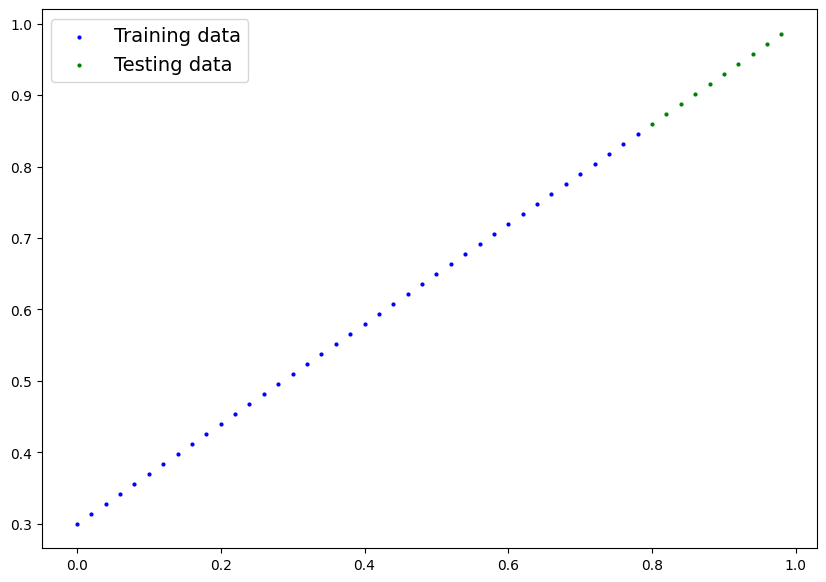

In [10]:
plot_perdictions()

## 🔵 2. Build the Model

Our first PyTorch Model!

We create a linear regression model. The formula: `Y = aX + B`

The whole goal of our model is to start with random numbers and parameters, look at the data (training data), and update those random numbers to represent the data. 

This way, we have a formula that represents the data we have, and it will work for any other unseen data. 

**What does our Model do?**
1. Start with random values (weight and bias)
2. Look at training data
3. Adjust the random values to get closer to ideal values (the weight and bias that created our data)

**How does it do so?** Two main algorithms:
1. Gradient descent
2. Backpropagation

In [13]:
# Create linear regression model class. 
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch inherhits from nn.Module
    '''
        For a class we need: 
        - its constants and global variables, 
        - attributes, 
        - constructor, 
        - modifiers and accessors, 
        - and computational methods. 

        What do we need? 
                1. subclass nn.Module --> contains all the building blocks 
                in neural networks. 

                2. Model parameters --> We make all the variables and paramters 
                we need for our model, like bias, weights, and more. 

                3. requires_grad = True means the pytorch will take care 
                of the gradients. 

                4. ANY SUBCLASS OF nn.Module NEEDS a forward() method!!
                Goal of forward: Defines the computation that model do. 
                Such as the linear regression formula ax + b
    '''
    
    # Constructor:
    def __init__(self):
        super().__init__()
        # nn.Paramer is a kind of tensor
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float), # <- PyTorch loves float32 by default
                                   requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float), # <- PyTorch loves float32 by default
                                   requires_grad=True) # <- can we update this value with gradient descent?)


    # Forward method to define the computation in the model:
    def forward(self, x: torch.tensor) -> torch.Tensor: # <- x is the input data
        
        # this is the linear regression formula (y = m*x + b)
        return self.weights * x + self.bias


## 🔵 3. Model Building classes in PyTorch 

1. torch.nn - Contains all of the building blocks for computational graphs (a neural network can be considered a computationla graph)
2. torch.nn.Prameter - What prarmeters our model try and learn, often a PyTorch Layer from torch.nn will set these for us.
3. torch.nn.Module - The base class for all neura lnetwork moduels. If you subclass it, you should override forward().
4. torch.optim - this where the optimise in PyTorch Live, they will help with **gradient descent**
5. def forward() - All nn.Module subclasses require you to override forward(), this method define what happens in the computation of our model. 


**PyTorch Cheat Sheet:** https://docs.pytorch.org/tutorials/index.html

### 🟢 4. Review the steps: 

1. Getting the data ready:


   `torchvision.transforms`

   
   `torch.utils.data.Dataset`

   
   `torch.utils.data.DataLoader`

3. Building a pretrained model:


    `torch.nn`

   
    `torch.nn.Module`

   
    `torchvision.models`
   

4. Optimizing the model:

    `torch.optim`


And there are more as well that we will continue learning!

 ## 🔵 Contents of Linear Regression Model:

 Now we created a model, let's see what's inside. 

 So we can check out our model prarmeters or what's inside the model using `.parameters()` or `modelName.state_dict()`

In [16]:
# create a random seed: 
# We need to have these randomizations saved. 

torch.manual_seed(42)

# create an instance of the model (this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

list(model_0.parameters())

# Our model has started with random values and parameters; our ideal model will look at the training model
# and adjust those values to best represent the data. 

# But we also have the known parameters; our whole goal is to change these random parameters
# to the known values. 


[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [17]:
# List named parameters: 
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [18]:
weight, bias

(0.7, 0.3)

### 🟢 Making Perdictions of Model:

We use `torch.inference_model()`

Torch checks our model's predictive power, we see how well it predicts the `y_test` based on `x_test`. 

When we pass data through our model, it's going to run it through the `forward()` method. 

In [23]:
print("The ideal model will take the first set of tensors as X, and outputs those y values. ")
print(X_test)
print()
print(y_test)

The ideal model will take the first set of tensors as X, and outputs those y values. 
tensor([[0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800],
        [0.9000],
        [0.9200],
        [0.9400],
        [0.9600],
        [0.9800]])

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])


In [26]:
# Make predictions with the model. 
y_preds = model_0(X_test)
print(y_preds)


# Better way to do it:
# This way the computation will be faster. 

with torch.inference_mode(): 
    y_preds_better = model_0(X_test)

print(y_preds_better)

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


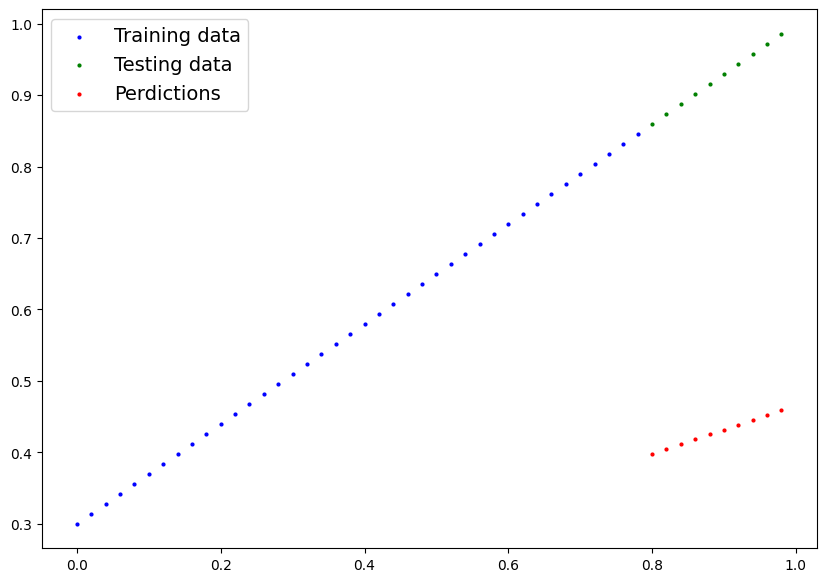

In [24]:
plot_perdictions(perdictions=y_preds_better)

## 🔵 4. Train Model

The whole idea of training a model is to move from some unknown parameters to some known parameters. 

Things we need to train: 

* **Loss Function** (Cost function): Measuring the poorness of models' predictions.
* They are a function to measure how wrong your model's predictions are compared to ideal outputs. So the lower, the better.
* **Optimizer**: Takes into account the loss of a model and adjusts the model's parameters (e.g. weights and biases)